# R² threshold comparison across configurations

For each **configuration** (experiment folder), we load `train_r2_scores.csv` and `test_r2_scores.csv` from every `run_*` directory.

**Per run**, we compute the **fraction of genes** (one R² per gene in the CSV) with \(R^2 > 0.01\) or \(R^2 > 0.1\), for train and test separately — not a threshold on the run’s average R² across genes.

**Batching (threshold / bar / boxplot summaries):** runs are ordered by run index and grouped in tens. For each batch we **average each gene’s R² across those 10 runs**, then compute each proportion as the **fraction of genes** whose *batch-averaged* R² exceeds 0.01 or 0.1 (not the average of the 10 per-run gene fractions). So 100 refits → **10** batch-level values per metric per configuration (incomplete tail batch dropped).

**Where we look:**
- `seed_gene_results/<experiment>/run_*` (skips `seed_genes_minmax_*` experiment names)
- `seed_genes_results/<experiment>/run_*` if that directory exists
- Any **top-level** directory under this folder whose name starts with `seed_genes_` (e.g. `seed_genes_T_brr_lr001_log1p`)

Adjust `SRC_DIR` in the next cell if your layout differs.

**Mean \(R^2\) (overfitting):** scatter plots use **each gene in each batch of 10 runs** as a point (mean train/test \(R^2\) for that gene **within** those 10 refits), so you get \((\#\mathrm{runs}/10)\times\#\mathrm{genes}\) points per configuration. The gap boxplot still uses **genome-wide** mean \(R^2\) per batch of 10.

In [ ]:
from __future__ import annotations

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Directory that contains seed_gene_results, seed_genes_results (optional), and/or seed_genes_* run folders
SRC_DIR = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src"
BATCH_SIZE = 10

# Experiment folders under seed_gene_results whose names start with any of these are skipped
IGNORE_EXPERIMENT_PREFIXES = ("seed_genes_minmax_",)
# Top-level seed_genes_* dirs to skip
IGNORE_TOPLEVEL_PREFIXES = ("seed_genes_minmax_",)

RUN_DIR_RE = re.compile(r"^run_(\d+)$", re.I)


def run_index(name: str) -> int | None:
    m = RUN_DIR_RE.match(name)
    return int(m.group(1)) if m else None


def list_runs(config_path: str) -> list[tuple[int, str]]:
    """Return sorted list of (run_number, full_path)."""
    out = []
    for name in os.listdir(config_path):
        ri = run_index(name)
        if ri is None:
            continue
        p = os.path.join(config_path, name)
        if os.path.isdir(p):
            out.append((ri, p))
    out.sort(key=lambda t: t[0])
    return out


def prop_above(path: str, fname: str, thr: float) -> float | None:
    """Fraction of genes (CSV rows) with R² > thr for this run/split."""
    fp = os.path.join(path, fname)
    if not os.path.isfile(fp):
        return None
    try:
        df = pd.read_csv(fp)
        if "r2" not in df.columns:
            return None
        r = df["r2"].astype(float)
        if len(r) == 0:
            return None
        return float(np.mean(r > thr))
    except Exception:
        return None


def mean_r2(path: str, fname: str) -> float | None:
    """Mean per-gene R² in one split (train or test CSV)."""
    fp = os.path.join(path, fname)
    if not os.path.isfile(fp):
        return None
    try:
        df = pd.read_csv(fp)
        if "r2" not in df.columns:
            return None
        r = df["r2"].astype(float)
        if len(r) == 0:
            return None
        return float(r.mean())
    except Exception:
        return None


def run_level_metrics(run_path: str) -> dict | None:
    """Per run: threshold proportions + mean R² (train/test)."""
    t001_tr = prop_above(run_path, "train_r2_scores.csv", 0.01)
    t01_tr = prop_above(run_path, "train_r2_scores.csv", 0.1)
    t001_te = prop_above(run_path, "test_r2_scores.csv", 0.01)
    t01_te = prop_above(run_path, "test_r2_scores.csv", 0.1)
    m_tr = mean_r2(run_path, "train_r2_scores.csv")
    m_te = mean_r2(run_path, "test_r2_scores.csv")
    if any(
        x is None
        for x in (t001_tr, t01_tr, t001_te, t01_te, m_tr, m_te)
    ):
        return None
    return {
        "prop_train_gt_001": t001_tr,
        "prop_train_gt_01": t01_tr,
        "prop_test_gt_001": t001_te,
        "prop_test_gt_01": t01_te,
        "mean_r2_train": m_tr,
        "mean_r2_test": m_te,
    }


def discover_configurations(src_dir: str) -> list[tuple[str, str]]:
    """Return list of (configuration_label, path_to_config_root_with_runs)."""
    configs: list[tuple[str, str]] = []
    seen: set[str] = set()

    def add(label: str, path: str) -> None:
        ap = os.path.abspath(path)
        if ap in seen:
            return
        if not os.path.isdir(ap):
            return
        seen.add(ap)
        configs.append((label, ap))

    for nested_name in ("seed_gene_results", "seed_genes_results"):
        root = os.path.join(src_dir, nested_name)
        if not os.path.isdir(root):
            continue
        for exp in sorted(os.listdir(root)):
            if any(exp.startswith(p) for p in IGNORE_EXPERIMENT_PREFIXES):
                continue
            p = os.path.join(root, exp)
            if not os.path.isdir(p):
                continue
            add(f"{nested_name}/{exp}", p)

    for name in sorted(os.listdir(src_dir)):
        if not name.startswith("seed_genes_"):
            continue
        if name in ("seed_genes_results",):
            continue
        if any(name.startswith(p) for p in IGNORE_TOPLEVEL_PREFIXES):
            continue
        p = os.path.join(src_dir, name)
        if os.path.isdir(p):
            add(name, p)

    return configs


def load_train_test_r2_per_gene(run_path: str) -> pd.DataFrame | None:
    """Per run: columns gene, r2_train, r2_test."""
    tp = os.path.join(run_path, "train_r2_scores.csv")
    sp = os.path.join(run_path, "test_r2_scores.csv")
    if not (os.path.isfile(tp) and os.path.isfile(sp)):
        return None
    try:
        a = pd.read_csv(tp)
        b = pd.read_csv(sp)
        if "gene" not in a.columns or "r2" not in a.columns:
            return None
        if "gene" not in b.columns or "r2" not in b.columns:
            return None
        m = a[["gene", "r2"]].merge(b[["gene", "r2"]], on="gene", suffixes=("_train", "_test"))
        if m.empty:
            return None
        m["r2_train"] = m["r2_train"].astype(float)
        m["r2_test"] = m["r2_test"].astype(float)
        return m[["gene", "r2_train", "r2_test"]]
    except Exception:
        return None



def configuration_batch_table(
    src_dir: str, batch_size: int = BATCH_SIZE
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns
    -------
    batch_df : one row per (configuration, batch_id)
        For each batch of runs, per-gene train/test R² is averaged across those runs.
        prop_* columns are the **fraction of genes** whose batch-averaged R² exceeds
        0.01 or 0.1 (not the mean of per-run gene fractions).
        mean_r2_* are means across genes of those batch-averaged R² values.
    run_df : one row per run; per-run prop_* are gene fractions for that run only.
    """
    run_rows = []
    batch_rows = []

    for cfg_label, cfg_path in discover_configurations(src_dir):
        runs = list_runs(cfg_path)
        for ri, rp in runs:
            m = run_level_metrics(rp)
            if m is None:
                continue
            run_rows.append({"configuration": cfg_label, "run_index": ri, "run_path": rp, **m})

        valid_paths = [(ri, rp) for ri, rp in runs if run_level_metrics(rp) is not None]
        for b_start in range(0, len(valid_paths), batch_size):
            chunk = valid_paths[b_start : b_start + batch_size]
            if len(chunk) < batch_size:
                continue
            dfs = [load_train_test_r2_per_gene(rp) for _, rp in chunk]
            if any(d is None for d in dfs):
                continue
            parts = []
            for i, d in enumerate(dfs):
                dd = d.copy()
                dd["_run"] = i
                parts.append(dd)
            long_df = pd.concat(parts, ignore_index=True)
            g = long_df.groupby("gene", as_index=False).agg(
                r2_train=("r2_train", "mean"),
                r2_test=("r2_test", "mean"),
                n=("r2_train", "count"),
            )
            g = g[g["n"] == batch_size]
            if g.empty:
                continue
            bid = b_start // batch_size
            batch_rows.append(
                {
                    "configuration": cfg_label,
                    "batch_id": bid,
                    "prop_train_gt_001": float((g["r2_train"] > 0.01).mean()),
                    "prop_train_gt_01": float((g["r2_train"] > 0.1).mean()),
                    "prop_test_gt_001": float((g["r2_test"] > 0.01).mean()),
                    "prop_test_gt_01": float((g["r2_test"] > 0.1).mean()),
                    "mean_r2_train": float(g["r2_train"].mean()),
                    "mean_r2_test": float(g["r2_test"].mean()),
                }
            )

    return pd.DataFrame(batch_rows), pd.DataFrame(run_rows)


def valid_run_paths_with_pairs(cfg_path: str) -> list[tuple[int, str]]:
    """Runs in order that have paired train/test per-gene R² CSVs."""
    out = []
    for ri, rp in list_runs(cfg_path):
        if load_train_test_r2_per_gene(rp) is not None:
            out.append((ri, rp))
    return out


def gather_per_gene_per_batch_averages(
    src_dir: str, batch_size: int = BATCH_SIZE
) -> pd.DataFrame:
    """
    For each configuration: group runs into consecutive batches of `batch_size`.
    Within each batch, for each gene, average train R² and test R² across those runs.

    Returns one row per (configuration, batch_id, gene) with columns
    mean_r2_train, mean_r2_test.  With 100 runs and 60 genes you get 10 * 60 points
    per configuration (genes missing in any run of the batch are dropped).
    """
    rows = []
    for cfg_label, cfg_path in discover_configurations(src_dir):
        valid_paths = valid_run_paths_with_pairs(cfg_path)
        for b_start in range(0, len(valid_paths), batch_size):
            chunk = valid_paths[b_start : b_start + batch_size]
            if len(chunk) < batch_size:
                continue
            dfs = [load_train_test_r2_per_gene(rp) for _, rp in chunk]
            if any(d is None for d in dfs):
                continue
            parts = []
            for i, d in enumerate(dfs):
                dd = d.copy()
                dd["_run"] = i
                parts.append(dd)
            long_df = pd.concat(parts, ignore_index=True)
            g = long_df.groupby("gene", as_index=False).agg(
                mean_r2_train=("r2_train", "mean"),
                mean_r2_test=("r2_test", "mean"),
                n=("r2_train", "count"),
            )
            g = g[g["n"] == batch_size].drop(columns=["n"])
            g["batch_id"] = b_start // batch_size
            g["configuration"] = cfg_label
            rows.append(g)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


batch_df, run_df = configuration_batch_table(SRC_DIR)
gene_batch_avg_df = gather_per_gene_per_batch_averages(SRC_DIR)
print(f"Configurations (batch_df): {batch_df['configuration'].nunique()}")
print(f"Batch rows: {len(batch_df)}, run rows: {len(run_df)}")
print(
    f"Scatter-point rows (gene × batch × configuration): {len(gene_batch_avg_df)} "
    f"({gene_batch_avg_df['configuration'].nunique()} configs)"
)
if len(gene_batch_avg_df):
    vc = gene_batch_avg_df.groupby("configuration").size()
    print("Example rows per configuration (should be ≈ n_batches × n_genes):", vc.head(4).to_string())
batch_df.head(12)


## Summary: mean ± std across batches

For **proportions**, each batch value is already the **fraction of genes** after averaging each gene’s R² across the 10 runs (see first cell). We then report **mean ± std** of those batch values across batches (e.g. 10 batches → 10 values).

In [8]:
METRICS = [
    ("prop_train_gt_001", r"Train: frac $R^2>0.01$"),
    ("prop_train_gt_01", r"Train: frac $R^2>0.1$"),
    ("prop_test_gt_001", r"Test: frac $R^2>0.01$"),
    ("prop_test_gt_01", r"Test: frac $R^2>0.1$"),
]

MEAN_R2_METRICS = [
    ("mean_r2_train", "Mean train R² (across genes)"),
    ("mean_r2_test", "Mean test R² (across genes)"),
]


def summarize_batches(batch_df: pd.DataFrame) -> pd.DataFrame:
    if batch_df.empty:
        return pd.DataFrame()
    rows = []
    for cfg, sub in batch_df.groupby("configuration"):
        row = {"configuration": cfg, "n_batches": len(sub)}
        for col, _ in METRICS:
            v = sub[col].astype(float)
            row[f"{col}_mean"] = v.mean()
            row[f"{col}_std"] = v.std(ddof=1) if len(v) > 1 else 0.0
        for col, _ in MEAN_R2_METRICS:
            if col in sub.columns:
                v = sub[col].astype(float)
                row[f"{col}_mean"] = v.mean()
                row[f"{col}_std"] = v.std(ddof=1) if len(v) > 1 else 0.0
        rows.append(row)
    out = pd.DataFrame(rows)
    sort_key = "prop_test_gt_001_mean"
    if sort_key in out.columns:
        out = out.sort_values(sort_key, ascending=False)
    return out


summary_df = summarize_batches(batch_df)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
summary_df


,configuration,n_batches,prop_train_gt_001_mean,prop_train_gt_001_std,prop_train_gt_01_mean,prop_train_gt_01_std,prop_test_gt_001_mean,prop_test_gt_001_std,prop_test_gt_01_mean,prop_test_gt_01_std,mean_r2_train_mean,mean_r2_train_std,mean_r2_test_mean,mean_r2_test_std
4,seed_gene_results/seed_genes_noT_brr,10,1.000000,0.000000,0.938833,0.004378,1.000000,0.000000,0.969833,0.002144,0.321522,0.002913,0.292835,0.001650
0,seed_gene_results/seed_genes_T_brr,10,0.999500,0.001125,0.934000,0.011790,0.999333,0.001610,0.966000,0.014745,0.312017,0.009335,0.287775,0.007838
2,seed_gene_results/seed_genes_T_brr_clip10,7,1.000000,0.000000,0.927381,0.002520,0.997381,0.002520,0.968810,0.001854,0.319978,0.001365,0.294446,0.001090
3,seed_gene_results/seed_genes_T_brr_clip5,10,1.000000,0.000000,0.927000,0.001892,0.997000,0.002194,0.970667,0.003784,0.316589,0.000530,0.292946,0.000917
10,seed_genes_T_brr_lr05_log1p_center,2,1.000000,0.000000,0.917500,0.001179,0.995833,0.001179,0.967500,0.001179,0.308076,0.000488,0.284736,0.001303
1,seed_gene_results/seed_genes_T_brr_clip1,10,0.999333,0.001165,0.914500,0.003244,0.995000,0.003043,0.959667,0.007320,0.290771,0.002430,0.275117,0.002202
5,seed_gene_results/seed_genes_nowg,10,0.993833,0.010542,0.897833,0.035303,0.992000,0.010328,0.922833,0.035591,0.261498,0.013619,0.254913,0.012219
12,seed_genes_T_brr_lr1_log1p_center,1,0.991667,0.000000,0.875000,0.000000,0.986667,0.000000,0.900000,0.000000,0.280828,0.000000,0.261517,0.000000
9,seed_genes_T_brr_lr05_log1p,1,0.873333,0.000000,0.641667,0.000000,0.876667,0.000000,0.700000,0.000000,0.230599,0.000000,0.214947,0.000000
6,seed_gene_results/seed_genes_nowg_norhog,10,0.764167,0.067537,0.312000,0.079880,0.737000,0.061039,0.323500,0.084887,0.095958,0.017378,0.097648,0.017590


## Plots

1. **Horizontal boxplots** — each configuration shows the **distribution across batches** (typically 10 values). For proportion metrics, each value is the **fraction of genes** with batch-averaged \(R^2\) above the cutoff. Wider boxes mean more variability between batches.
2. **Bar chart** — mean test metrics with error bars (std across batches).
3. **Heatmap** — mean of each metric per configuration for a compact ranking.


/scratch/ipykernel_2977918/1474088620.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=configs, patch_artist=True)
/scratch/ipykernel_2977918/1474088620.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=configs, patch_artist=True)
/scratch/ipykernel_2977918/1474088620.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=configs, patch_artist=True)
/scratch/ipykernel_2977918/1474088620.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

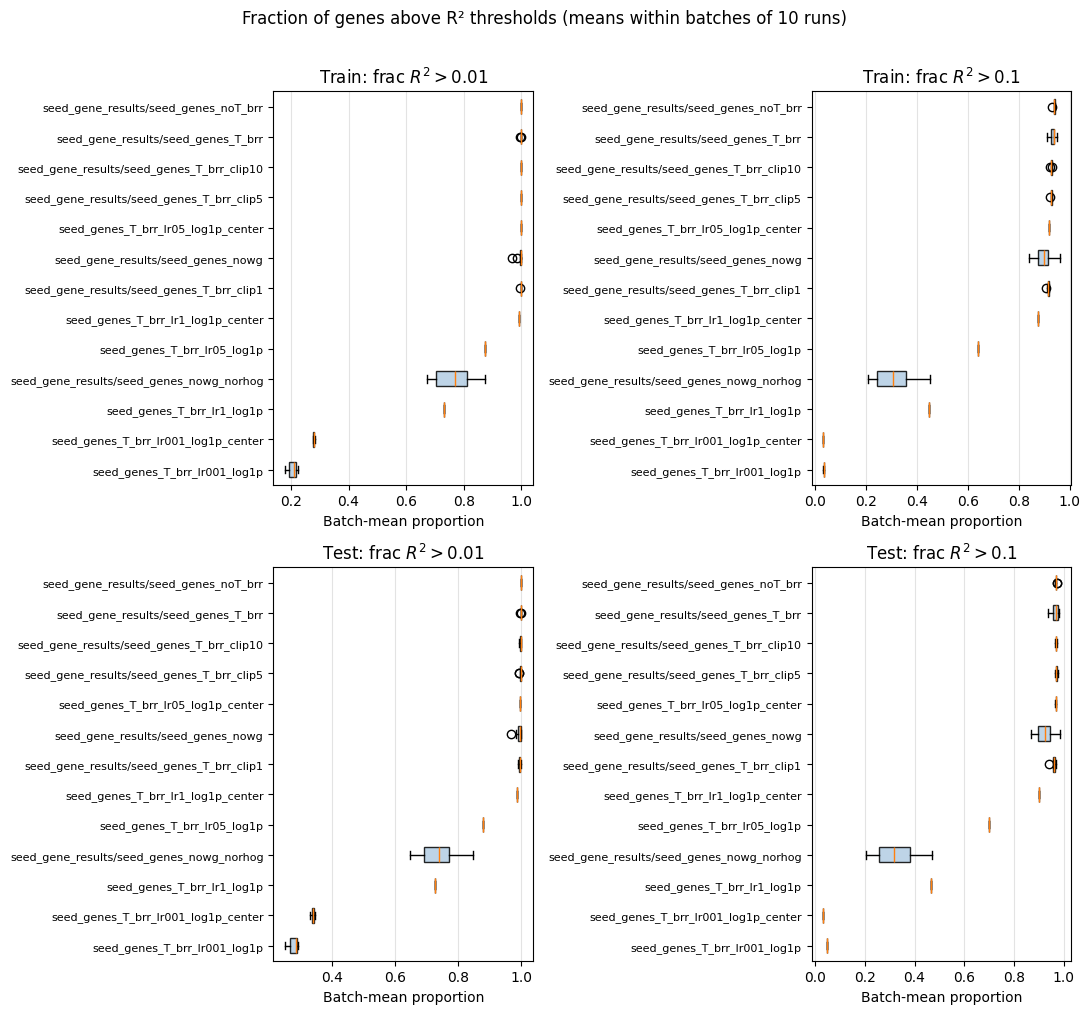

In [9]:
def _order_configurations(batch_df: pd.DataFrame) -> list[str]:
    if batch_df.empty:
        return []
    med = batch_df.groupby("configuration")["prop_test_gt_001"].median().sort_values()
    return list(med.index)


def plot_boxplots_four_panels(batch_df: pd.DataFrame, figsize=(11, 10)):
    if batch_df.empty:
        print("No batch data to plot.")
        return
    configs = _order_configurations(batch_df)
    if not configs:
        return
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=False)
    axes = axes.ravel()
    for ax, (col, title) in zip(axes, METRICS):
        data = [batch_df.loc[batch_df["configuration"] == c, col].values.astype(float) for c in configs]
        bp = ax.boxplot(data, vert=False, labels=configs, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor("#b3cde3")
            patch.set_alpha(0.85)
        ax.set_xlabel("Batch-mean proportion")
        ax.set_title(title)
        ax.grid(axis="x", alpha=0.35)
        ax.tick_params(axis="y", labelsize=8)
    fig.suptitle(
        f"Fraction of genes above R² thresholds (means within batches of {BATCH_SIZE} runs)",
        fontsize=12,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()


plot_boxplots_four_panels(batch_df)

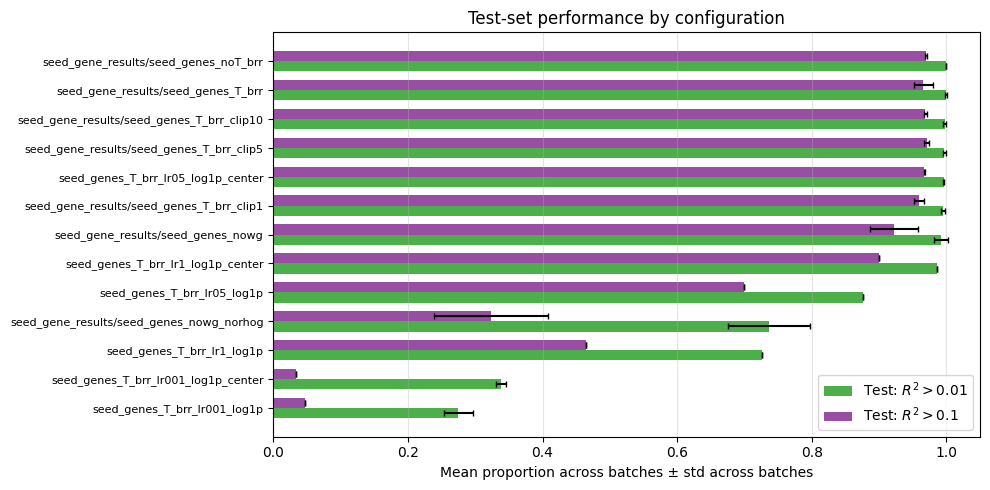

In [10]:
def plot_test_bars_with_errors(summary_df: pd.DataFrame, figsize=(10, 5)):
    if summary_df.empty:
        return
    sub = summary_df.sort_values("prop_test_gt_001_mean", ascending=True).copy()
    y = np.arange(len(sub))
    h = 0.35
    x1 = sub["prop_test_gt_001_mean"].values
    e1 = sub["prop_test_gt_001_std"].values
    x2 = sub["prop_test_gt_01_mean"].values
    e2 = sub["prop_test_gt_01_std"].values
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(y - h / 2, x1, height=h, xerr=e1, capsize=2, label=r"Test: $R^2>0.01$", color="#4daf4a")
    ax.barh(y + h / 2, x2, height=h, xerr=e2, capsize=2, label=r"Test: $R^2>0.1$", color="#984ea3")
    ax.set_yticks(y)
    ax.set_yticklabels(sub["configuration"], fontsize=8)
    ax.set_xlabel("Mean proportion across batches ± std across batches")
    ax.set_title("Test-set performance by configuration")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1.05)
    ax.grid(axis="x", alpha=0.35)
    plt.tight_layout()
    plt.show()


plot_test_bars_with_errors(summary_df)

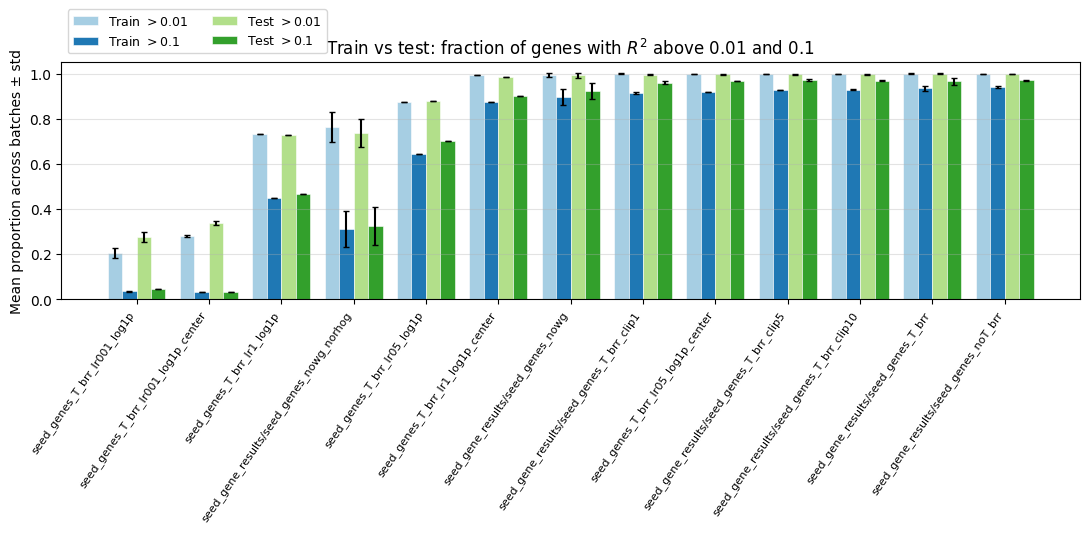

In [11]:
def plot_train_test_grouped_bars(summary_df: pd.DataFrame, figsize=(11, 6)):
    """Grouped bars: train vs test for both thresholds (mean ± std across batches)."""
    if summary_df.empty:
        return
    sub = summary_df.sort_values("prop_test_gt_001_mean", ascending=True).reset_index(drop=True)
    n = len(sub)
    cats = sub["configuration"].tolist()
    x = np.arange(n)
    w = 0.2
    fig, ax = plt.subplots(figsize=figsize)
    series = [
        ("train_gt_001", "prop_train_gt_001_mean", "prop_train_gt_001_std", "#a6cee3", r"Train $>0.01$"),
        ("train_gt_01", "prop_train_gt_01_mean", "prop_train_gt_01_std", "#1f78b4", r"Train $>0.1$"),
        ("test_gt_001", "prop_test_gt_001_mean", "prop_test_gt_001_std", "#b2df8a", r"Test $>0.01$"),
        ("test_gt_01", "prop_test_gt_01_mean", "prop_test_gt_01_std", "#33a02c", r"Test $>0.1$"),
    ]
    for i, (_, mcol, scol, color, lab) in enumerate(series):
        off = (i - 1.5) * w
        ax.bar(
            x + off,
            sub[mcol],
            width=w,
            yerr=sub[scol],
            capsize=2,
            label=lab,
            color=color,
            edgecolor="white",
            linewidth=0.4,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=55, ha="right", fontsize=8)
    ax.set_ylabel("Mean proportion across batches ± std")
    ax.set_ylim(0, 1.05)
    ax.legend(ncol=2, fontsize=9, loc="upper left", bbox_to_anchor=(0, 1.25))
    ax.set_title("Train vs test: fraction of genes with $R^2$ above 0.01 and 0.1")
    ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    plt.show()


plot_train_test_grouped_bars(summary_df)

## Train vs test mean \(R^2\) (overfitting)

**Scatter plots:** each point is one **gene in one batch of refits**. Runs are ordered by `run_*` index and split into consecutive groups of **10**. For each group, we average that gene’s train \(R^2\) and test \(R^2\) across those 10 runs. So with 100 runs and \(G\) genes you get **\((100/10) \times G\)** points per configuration (genes absent in any run of the batch are omitted).

The dashed line is \(y=x\). **Below** the line means lower mean test than mean train \(R^2\) within that batch.

The **gap** boxplot still uses **batches of 10 runs** at the **genome-wide** level (one mean train and one mean test \(R^2\) per batch over all genes).


In [ ]:
def plot_train_vs_test_mean_r2_overview(gene_df: pd.DataFrame, figsize=(7, 6)):
    """All configurations: each point = gene × batch; R² averaged over 10 runs in that batch."""
    need = {"mean_r2_train", "mean_r2_test", "configuration"}
    if gene_df.empty or not need.issubset(gene_df.columns):
        print("No gene-level batch data; re-run the first cell.")
        return
    sub = gene_df.dropna(subset=["mean_r2_train", "mean_r2_test"]).copy()
    if sub.empty:
        print("No data.")
        return
    cats = sub["configuration"].astype(str)
    codes, uniques = pd.factorize(cats)
    n = len(uniques)
    cmap = plt.cm.tab20
    norm = plt.Normalize(vmin=0, vmax=max(n - 1, 0))
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        sub["mean_r2_train"],
        sub["mean_r2_test"],
        c=codes,
        cmap=cmap,
        norm=norm,
        s=10,
        alpha=0.22,
        edgecolors="none",
    )
    lo = float(min(sub["mean_r2_train"].min(), sub["mean_r2_test"].min()))
    hi = float(max(sub["mean_r2_train"].max(), sub["mean_r2_test"].max()))
    pad = 0.02 * max(hi - lo, 1e-6)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1.2, alpha=0.55, label="y = x")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"Mean train $\bar{R}^2$ per gene (avg over 10 runs in batch)")
    ax.set_ylabel(r"Mean test $\bar{R}^2$ per gene (avg over 10 runs in batch)")
    ax.set_title("Train vs test $R^2$ per gene × batch (all configurations)")
    ax.grid(alpha=0.35)
    handles = [
        mlines.Line2D(
            [], [], color=cmap(norm(i)), marker="o", linestyle="", markersize=6, label=u
        )
        for i, u in enumerate(uniques)
    ]
    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=7,
        title="configuration",
    )
    plt.tight_layout()
    plt.show()


def plot_train_vs_test_mean_r2_facets(gene_df: pd.DataFrame, ncols: int = 3, figsize_per: float = 3.2):
    """One subplot per configuration; points = gene × batch (mean R² over 10 runs)."""
    if gene_df.empty or not {"mean_r2_train", "mean_r2_test"}.issubset(gene_df.columns):
        return
    cfgs = sorted(gene_df["configuration"].unique())
    n = len(cfgs)
    if n == 0:
        return
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * figsize_per, nrows * figsize_per),
        squeeze=False,
    )
    for idx, cfg in enumerate(cfgs):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sub = gene_df[gene_df["configuration"] == cfg]
        ax.scatter(
            sub["mean_r2_train"],
            sub["mean_r2_test"],
            alpha=0.35,
            s=10,
            edgecolors="none",
        )
        lo = float(min(sub["mean_r2_train"].min(), sub["mean_r2_test"].min()))
        hi = float(max(sub["mean_r2_train"].max(), sub["mean_r2_test"].max()))
        pad = 0.02 * max(hi - lo, 1e-6)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, alpha=0.45)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(cfg, fontsize=8)
        ax.set_xlabel(r"Train $\bar{R}^2$", fontsize=7)
        ax.set_ylabel(r"Test $\bar{R}^2$", fontsize=7)
        ax.grid(alpha=0.3)
    for j in range(len(cfgs), nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].set_visible(False)
    fig.suptitle("Per gene × batch: mean $R^2$ over 10 runs", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_mean_r2_gap_boxplot(batch_df: pd.DataFrame, figsize=(10, 6)):
    """Train minus test mean R² per batch (higher ⇒ larger gap / more overfitting)."""
    if batch_df.empty or not {"mean_r2_train", "mean_r2_test"}.issubset(batch_df.columns):
        return
    sub = batch_df.dropna(subset=["mean_r2_train", "mean_r2_test"]).copy()
    sub["gap_train_minus_test"] = sub["mean_r2_train"] - sub["mean_r2_test"]
    cfgs = sorted(sub["configuration"].unique())
    data = [sub.loc[sub["configuration"] == g, "gap_train_minus_test"].values for g in cfgs]
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(data, vert=False, labels=cfgs, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#fdb462")
        patch.set_alpha(0.85)
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.set_xlabel(r"Batch: mean train $\bar{R}^2$ − mean test $\bar{R}^2$")
    ax.set_title("Overfitting gap (per batch of 10 runs)")
    ax.grid(axis="x", alpha=0.35)
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()


plot_train_vs_test_mean_r2_overview(gene_batch_avg_df)
plot_train_vs_test_mean_r2_facets(gene_batch_avg_df)
plot_mean_r2_gap_boxplot(batch_df)
